<a href="https://colab.research.google.com/github/sagasucksatlife1/QuantProjects/blob/main/RiskParityPortfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RISK PARITY PORTFOLIO**

This project explores different approaches to portfolio construction, focusing on how risk and return can be managed using quantitative methods. We begin with a simple equal-weight portfolio as a baseline, then build a Markowitz portfolio to maximize risk-adjusted returns, and a risk parity portfolio to balance risk contributions across assets. To enhance performance, we further apply leverage to the risk parity portfolio, scaling it to a desired level of risk. Throughout the process, we compute key metrics like return, volatility, and Sharpe ratio, and finally compare all approaches visually using a risk-return graph to understand their trade-offs.

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

Let us take a random porfolio, where the amonut is invested equally across all the 10 companies each the top in its own sector, we will demonstrate all the portfolio optimization across all the portfolio on this portfolio

In [130]:
tickers = ["HDFCBANK.NS","RELIANCE.NS","TCS.NS","SUNPHARMA.NS", "HINDUNILVR.NS", "LT.NS","MARUTI.NS","ULTRACEMCO.NS",
 "BHARTIARTL.NS","ADANIENT.NS"]

portfolio_data = yf.download(tickers, start= '2020-01-01', interval= "1d")["Close"]
portfolio_data.head()
portfolio_data = portfolio_data.dropna()
returns = portfolio_data.pct_change()
annual_returns= returns.mean() * 252
cov_matrix = returns.cov()*252
print(cov_matrix)

/tmp/ipykernel_379/4114287988.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_data = yf.download(tickers, start= '2020-01-01', interval= "1d")["Close"]
[*********************100%***********************]  10 of 10 completed

Ticker         ADANIENT.NS  BHARTIARTL.NS  HDFCBANK.NS  HINDUNILVR.NS  \
Ticker                                                                  
ADANIENT.NS       0.257696       0.037130     0.040569       0.018714   
BHARTIARTL.NS     0.037130       0.072708     0.023948       0.014138   
HDFCBANK.NS       0.040569       0.023948     0.065830       0.014109   
HINDUNILVR.NS     0.018714       0.014138     0.014109       0.053477   
LT.NS             0.047765       0.025599     0.035340       0.014534   
MARUTI.NS         0.045101       0.026288     0.029980       0.021385   
RELIANCE.NS       0.048579       0.024269     0.031605       0.019741   
SUNPHARMA.NS      0.029145       0.020272     0.016154       0.013124   
TCS.NS            0.029183       0.018037     0.018541       0.016700   
ULTRACEMCO.NS     0.047110       0.024547     0.030634       0.020594   

Ticker            LT.NS  MARUTI.NS  RELIANCE.NS  SUNPHARMA.NS    TCS.NS  \
Ticker                                          

here first of all we calcultaed daily returns of all the stocks then we use those to calculate annual retuns and the co 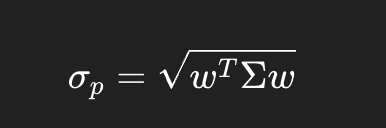- variance matrix.

In [131]:
#initial weight
weight = np.array([0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10 ])
portfolio_return = np.dot(weight, annual_returns)
portfolio_variance = np.dot(weight.T, np.dot(cov_matrix, weight))
portfolio_volatility = np.sqrt(portfolio_variance)
sharpe_ratio = (portfolio_return - 0.02) / portfolio_volatility
print("portfolio_return")
print(portfolio_return*100)
print("portfolio_volatility")
print(portfolio_volatility*100)
print("portfolio_sharpe")
print(sharpe_ratio)

portfolio_return
19.71901716171397
portfolio_volatility
18.086554318135413
portfolio_sharpe
0.9796789841803694


After calcuting the co variance matrix we use it to determine the portfolio returns, portfolio volatility, sharpe ratio of the portfolio.

In [132]:
from scipy.optimize import minimize
def negative_sharpe(weight):
    portfolio_return = np.dot(weight, annual_returns)
    portfolio_variance = np.dot(weight.T, np.dot(cov_matrix, weight))
    portfolio_volatility = np.sqrt(portfolio_variance)
    sharpe = (portfolio_return - 0.02) / portfolio_volatility
    return -sharpe
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bound = [(0,1)] * len(weight)


result = minimize(negative_sharpe, weight, method='SLSQP',
                  bounds=bound, constraints=constraints)
Markowitz_weight = result.x
print("Optimal weights:", Markowitz_weight)


Optimal weights: [1.79503687e-01 2.96453337e-01 0.00000000e+00 6.50385778e-17
 6.06782527e-02 6.04036135e-17 2.82100122e-17 4.31418374e-01
 0.00000000e+00 3.19463489e-02]


we craeted a function called neagtive sharpe that calcutes sharpe values and retuns -sharpe, then we used it to minimize the shapre and get optimized weight for which the sharpe of the portfolio is most neagtive or highhest in the maginitude.

In [133]:

Markowtiz_optimal_return = np.dot(Markowitz_weight,annual_returns)
Markowitz_optimal_variance = np.dot(Markowitz_weight.T, np.dot(cov_matrix, Markowitz_weight))
Markowtiz_optimal_volatility = np.sqrt(Markowitz_optimal_variance)
Markowtiz_optimal_sharpe = (Markowtiz_optimal_return - 0.02) / Markowtiz_optimal_volatility
print("Markowtiz_optimal_return")
print(Markowtiz_optimal_return*100)
print("Markowtiz_optimal_volatility")
print(Markowtiz_optimal_volatility*100)
print("Markowtiz_optimal_sharpe")
print(Markowtiz_optimal_sharpe)

Markowtiz_optimal_return
30.617754953922567
Markowtiz_optimal_volatility
21.166096484551932
Markowtiz_optimal_sharpe
1.352056340422015


In [134]:
MRC = np.dot(cov_matrix,weight)/portfolio_volatility
Risk_contribution = MRC * weight
print(Risk_contribution)

[0.03322873 0.0158646  0.01695786 0.01141828 0.01932337 0.01932373
 0.01918987 0.0132177  0.01350346 0.01883794]


Marginal Risk Contribution : key technical concept used to calculate how the total portfolio volatility changes with a small increase in an asset's weight.

Risk contribution is the contirbutuion of each assest in the portfolio whose summation isthe portfolio volatility

the aim of the risk-parity portfolio is to optimize weight in a way that thr risk contibution of each ssest becomes the same.

In [135]:
measured_Risk_contribution = portfolio_volatility / 10
print("Measured_Risk_contribution")
print(measured_Risk_contribution)

Measured_Risk_contribution
0.01808655431813541


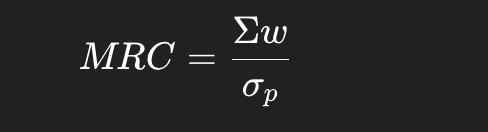

In [136]:
difference = Risk_contribution - measured_Risk_contribution
print("differnce")
print(difference)

differnce
[ 0.01514218 -0.00222195 -0.0011287  -0.00666827  0.00123682  0.00123717
  0.00110332 -0.00486885 -0.0045831   0.00075139]


In [137]:
def objective(weight):
  portfolio_volatility = np.sqrt(np.dot(weight.T, np.dot(cov_matrix, weight)))
  MRC = np.dot(cov_matrix,weight)/portfolio_volatility
  Risk_contribution = MRC * weight
  measured_Risk_contribution = portfolio_volatility / len(weight)
  difference = Risk_contribution - measured_Risk_contribution
  return np.sum(difference**2)

We started by defining a portfolio using weights and a covariance matrix, which tells us how assets move together. From this, we calculated the total portfolio risk (volatility) and then broke that risk into parts, figuring out how much each asset contributes to the overall risk. This gave us a clear view of which assets are dominating the portfolio and which are underrepresented in terms of risk.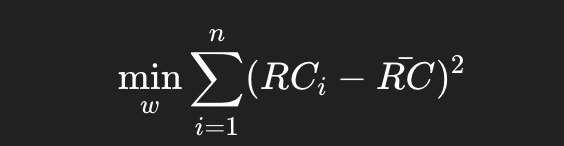

In [138]:
from scipy.optimize import minimize
constain = ({'type':'eq', 'fun': lambda x: np.sum(x)-1})
bound = [(0,1)] * len(weight)
result = minimize(objective, weight, method='SLSQP', bounds=bound, constraints=constain)
optimal_weight = result.x
print(optimal_weight)

[0.05891818 0.10757846 0.10151368 0.13159288 0.08829786 0.08793202
 0.08915974 0.12277484 0.12115083 0.09108151]


Next, we set a goal: every asset should contribute equally to the total risk. To measure how far we are from this goal, we calculated the difference between each asset’s actual risk contribution and the ideal equal share. We then built an objective function that adds up all these differences (squared), so the optimizer has a single number to minimize—basically a measure of how unbalanced the portfolio is.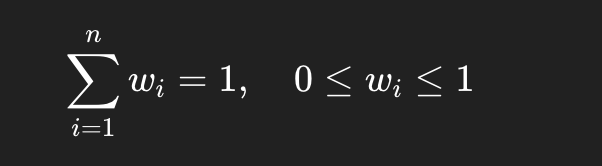

In [139]:
optimal_returns = np.dot(annual_returns,optimal_weight)
optimal_portfolio_volatility = np.sqrt(np.dot(optimal_weight.T, np.dot(cov_matrix, optimal_weight)))
optimal_sharpe_ratio = (optimal_returns - 0.02) / optimal_portfolio_volatility
print("optimal_returns")
print(optimal_returns)
print("optimal_portfolio_volatility")
print(optimal_portfolio_volatility)
print("optimal_sharpe_ratio")
print(optimal_sharpe_ratio)


optimal_returns
0.1807345216932308
optimal_portfolio_volatility
0.17103605144512107
optimal_sharpe_ratio
0.9397698341089472


Finally, we used an optimization algorithm to adjust the weights while keeping basic constraints like total weight equal to 1 and no negative weights. The optimizer keeps tweaking the weights until the risk contributions become as equal as possible. The result is a risk parity portfolio, where the focus is on balancing risk across assets rather than simply maximizing returns.

In [140]:
target_vol = 0.25
current_vol = optimal_portfolio_volatility

leverage = target_vol / current_vol
print("leverage")
print(leverage)

leverage
1.4616801422138503


After constructing the risk parity portfolio, we applied leverage to scale the portfolio to a higher target level of volatility. This was done by calculating a leverage factor as the ratio of desired volatility to current portfolio volatility, and then multiplying the portfolio weights by this factor. This effectively increases exposure while maintaining the same underlying risk structure.


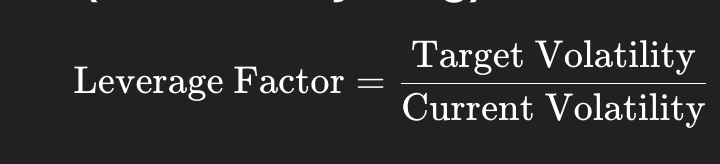

In [141]:
leveraged_weights = optimal_weight * leverage
new_return = np.dot(annual_returns, leveraged_weights)
new_vol = np.sqrt(np.dot(leveraged_weights.T,np.dot(cov_matrix,leveraged_weights)))
new_sharpe = (new_return - 0.02) / new_vol
print("new return after leverage")
print(new_return*100)
print("new volatility after leverage")
print(new_vol*100)
print("new sharpe after leverage")
print(new_sharpe)

new return after leverage
26.417606137151385
new volatility after leverage
24.999999999999996
new sharpe after leverage
0.9767042454860555


Once the leveraged weights were obtained, we recomputed the portfolio return, volatility, and Sharpe ratio. As expected, both return and volatility increased proportionally, while the Sharpe ratio remained roughly the same. This demonstrates that leverage scales both risk and return without improving risk-adjusted performance.

Finally, we visualized all four portfolios—equal weight, Markowitz (maximum Sharpe), risk parity, and leveraged risk parity—on a return vs volatility graph. This allows us to compare their risk-return profiles visually, highlighting the trade-offs between diversification, concentration, and performance across different portfolio construction methods.

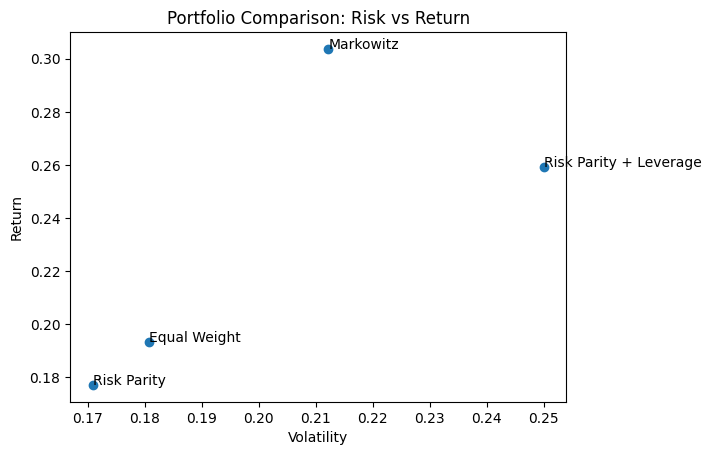

In [142]:
import matplotlib.pyplot as plt

labels = ["Equal Weight", "Markowitz", "Risk Parity", "Risk Parity + Leverage"]
returns = [0.193394654, 0.303709416, 0.17717295, 0.259226117]
vols = [0.18067993, 0.21220311, 0.17086719, 0.25]

plt.figure()
plt.scatter(vols, returns)

for i, label in enumerate(labels):
    plt.text(vols[i], returns[i], label)

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.title("Portfolio Comparison: Risk vs Return")

plt.show()

The equal-weight portfolio delivered a return of about 19.7% with 18.08% volatility and a Sharpe of 0.98, serving as a balanced baseline . The Markowitz portfolio significantly outperformed with a 30.6% return and Sharpe of 1.35, but this came at the cost of higher volatility (21.16%) and heavy concentration in a few assets, making it less diversified and more fragile. In contrast, the risk parity portfolio reduced volatility to 17.1% but also lowered returns to 18.07%, resulting in a slightly lower Sharpe (~0.94) due to its focus on equalizing risk rather than maximizing returns. However, when leverage was applied to the risk parity portfolio, returns increased to 26.4% with 25% volatility, and the Sharpe ratio improved back to ~0.97, showing that a well-diversified risk structure can be scaled efficiently to achieve competitive performance without relying on concentrated bets.